**موضوع:** تحلیل شبکه رودخانه‌های ایران و پیرامون در جنوب‌غرب آسیا  
**داده:** Natural Earth — Rivers + Lake Centerlines  
**مدل هوش مصنوعی:** Isolation Forest  
**هدف مدل:** شناسایی قطعات رودخانه‌ای که از نظر طول، پیچ‌وخم و موقعیت جغرافیایی نسبت به سایر قطعات غیرعادی هستند.

لینک مستقیم داده‌ها:

- Rivers: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
- Countries: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip

> محدوده مطالعه تقریباً ایران و کشورهای پیرامونی است تا تعداد کافی از عوارض خطی برای آموزش مدل وجود داشته باشد.


## سلول 1 — نصب و وارد کردن کتابخانه‌ها

در این مرحله کتابخانه‌های GIS، مصورسازی و یادگیری ماشین نصب و وارد می‌شوند.

- `geopandas`: تحلیل داده‌های مکانی
- `matplotlib`: نقشه ثابت
- `folium`: نقشه تعاملی
- `shapely`: عملیات هندسی
- `contextily`: نقشه پایه
- `scikit-learn`: اجرای Isolation Forest


In [1]:
import sys
import subprocess
import importlib.util

required_packages = {
    "geopandas": "geopandas",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "folium": "folium",
    "shapely": "shapely",
    "contextily": "contextily",
    "sklearn": "scikit-learn",
    "pyogrio": "pyogrio"
}

missing = [
    pip_name for module_name, pip_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", *missing
    ])

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
import contextily as ctx

from pathlib import Path
from urllib.request import urlretrieve
from shapely.geometry import box, Point
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from IPython.display import display

print("Libraries are ready.")
print("GeoPandas version:", gpd.__version__)


Libraries are ready.
GeoPandas version: 1.2.0


In [2]:
data_dir = Path("gis_river_ai_data")
data_dir.mkdir(exist_ok=True)

rivers_url = (
    "https://naturalearth.s3.amazonaws.com/10m_physical/"
    "ne_10m_rivers_lake_centerlines.zip"
)

countries_url = (
    "https://naturalearth.s3.amazonaws.com/110m_cultural/"
    "ne_110m_admin_0_countries.zip"
)

rivers_zip = data_dir / "ne_10m_rivers_lake_centerlines.zip"
countries_zip = data_dir / "ne_110m_admin_0_countries.zip"

if not rivers_zip.exists():
    print("Downloading rivers dataset...")
    urlretrieve(rivers_url, rivers_zip)

if not countries_zip.exists():
    print("Downloading countries dataset...")
    urlretrieve(countries_url, countries_zip)

rivers = gpd.read_file(f"zip://{rivers_zip.resolve()}")
countries = gpd.read_file(f"zip://{countries_zip.resolve()}")

rivers = rivers.to_crs("EPSG:4326")
countries = countries.to_crs("EPSG:4326")

admin_col = "ADMIN" if "ADMIN" in countries.columns else "NAME"
iran = countries[
    countries[admin_col].astype(str).str.casefold().eq("iran")
].copy()

print("Number of river features:", len(rivers))
print("Number of country features:", len(countries))
print("Iran boundary found:", len(iran) == 1)


Number of river features: 1473
Number of country features: 177
Iran boundary found: True


Shape: (1473, 39)
CRS: EPSG:4326

Geometry types:


LineString         1053
MultiLineString     420
Name: count, dtype: int64


Columns:
['dissolve', 'scalerank', 'featurecla', 'name', 'name_alt', 'rivernum', 'note', 'min_zoom', 'name_en', 'min_label', 'ne_id', 'label', 'wikidataid', 'name_ar', 'name_bn', 'name_de', 'name_es', 'name_fr', 'name_el', 'name_hi', 'name_hu', 'name_id', 'name_it', 'name_ja', 'name_ko', 'name_nl', 'name_pl', 'name_pt', 'name_ru', 'name_sv', 'name_tr', 'name_vi', 'name_zh', 'name_fa', 'name_he', 'name_uk', 'name_ur', 'name_zht', 'geometry']

First five rows:


,dissolve,scalerank,featurecla,name,name_alt,rivernum,note,min_zoom,name_en,min_label,...,name_sv,name_tr,name_vi,name_zh,name_fa,name_he,name_uk,name_ur,name_zht,geometry
0,975River,9,River,NaN,NaN,975,NaN,7.1,NaN,8.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (22.75649 -20.47161, 22.79458 -20.4..."
1,976River,9,River,Rungwa,NaN,976,NaN,7.1,Rungwa,8.1,...,Rungwa,Rungwa,Sông Rungwa,伦瓜河,رونگوا,רונגווה,Рунгва,رنگوا,倫瓜河,"MULTILINESTRING ((32 -7.24993, 32.02793 -7.238..."
2,977River,9,River,Ligonha,NaN,977,NaN,7.1,Ligonha,8.1,...,Ligonha,Ligonha,Sông Ligonha,利戈尼亚河,لیگونها,ליגונה,Лігонха,لیگونہا,利戈尼亞河,"MULTILINESTRING ((39.12783 -16.86663, 39.12598..."
3,978River,9,River,Dongwe,NaN,978,NaN,7.1,Dongwe,8.1,...,Dongwe,Dongwe,Sông Dongwe,松威河,دونگوه,דונגווה,Донгве,ڈانگوے,東威河,"LINESTRING (25.5333 -14.58333, 25.49502 -14.59..."
4,979River,9,River,Cuito,NaN,979,NaN,7.1,Cuito,8.1,...,Cuito,Cuito,Sông Cuito,奎托河,کیتو,קיטו,Куіто,کیوٹو,奎托河,"MULTILINESTRING ((20.75 -17.99993, 20.75234 -1..."


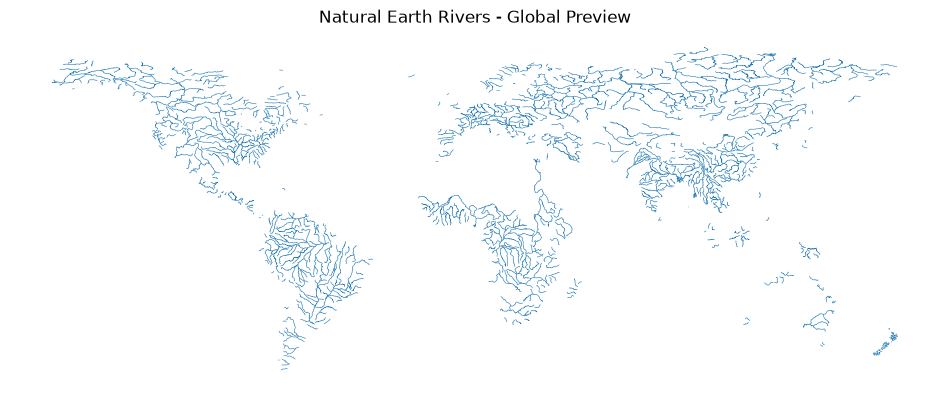

In [3]:
print("Shape:", rivers.shape)
print("CRS:", rivers.crs)

print("\nGeometry types:")
display(rivers.geom_type.value_counts())

print("\nColumns:")
print(list(rivers.columns))

print("\nFirst five rows:")
display(rivers.head())

ax = rivers.plot(figsize=(12, 6), linewidth=0.4)
ax.set_title("Natural Earth Rivers - Global Preview")
ax.set_axis_off()
plt.show()


## سلول 4 — انتخاب محدوده مطالعه و استخراج ویژگی‌های مکانی

برای اینکه مدل تعداد مناسبی نمونه داشته باشد، محدوده‌ای شامل ایران و کشورهای پیرامونی انتخاب می‌کنیم.

سپس:

1. رودخانه‌ها با محدوده مطالعه `Clip` می‌شوند.
2. هندسه‌های چندبخشی به قطعات ساده تبدیل می‌شوند.
3. داده‌ها به یک CRS متریک تبدیل می‌شوند.
4. ویژگی‌های زیر ساخته می‌شوند:

- `length_km`: طول هر قطعه
- `straight_km`: فاصله مستقیم ابتدا تا انتهای قطعه
- `sinuosity`: نسبت طول واقعی به فاصله مستقیم
- `centroid_lon`, `centroid_lat`: مرکز هندسی قطعه

هرچه `sinuosity` بزرگ‌تر باشد، خط رودخانه پیچ‌وخم بیشتری دارد.


In [4]:
study_area = gpd.GeoDataFrame(
    {"name": ["Southwest Asia Study Area"]},
    geometry=[box(42, 23, 66, 42)],
    crs="EPSG:4326"
)

rivers_region = gpd.clip(rivers, study_area)
rivers_region = rivers_region.explode(index_parts=False).reset_index(drop=True)
rivers_region = rivers_region[
    rivers_region.geometry.notna()
    & ~rivers_region.geometry.is_empty
    & rivers_region.geom_type.eq("LineString")
].copy()

metric_crs = (
    "+proj=aeqd +lat_0=32 +lon_0=54 "
    "+datum=WGS84 +units=m +no_defs +type=crs"
)

rivers_metric = rivers_region.to_crs(metric_crs).copy()
rivers_metric["length_km"] = rivers_metric.geometry.length / 1000

def end_to_end_distance_km(geom):
    coords = list(geom.coords)
    start = Point(coords[0])
    end = Point(coords[-1])
    return start.distance(end) / 1000

rivers_metric["straight_km"] = rivers_metric.geometry.apply(
    end_to_end_distance_km
)

rivers_metric["sinuosity"] = np.where(
    rivers_metric["straight_km"] > 0.05,
    rivers_metric["length_km"] / rivers_metric["straight_km"],
    np.nan
)

centroids_metric = gpd.GeoSeries(
    rivers_metric.geometry.centroid,
    crs=metric_crs
)
centroids_wgs84 = centroids_metric.to_crs("EPSG:4326")

rivers_metric["centroid_lon"] = centroids_wgs84.x.values
rivers_metric["centroid_lat"] = centroids_wgs84.y.values

rivers_metric = rivers_metric.replace([np.inf, -np.inf], np.nan)
rivers_metric = rivers_metric.dropna(
    subset=["length_km", "straight_km", "sinuosity",
            "centroid_lon", "centroid_lat"]
).reset_index(drop=True)

rivers_metric = rivers_metric[
    rivers_metric["length_km"] >= 1
].reset_index(drop=True)

rivers_region = rivers_metric.to_crs("EPSG:4326").copy()

print("River segments in study area:", len(rivers_region))

display(
    rivers_region[
        ["length_km", "straight_km", "sinuosity",
         "centroid_lon", "centroid_lat"]
    ].describe().round(2)
)


River segments in study area: 31


,length_km,straight_km,sinuosity,centroid_lon,centroid_lat
count,31.00,31.00,31.00,31.00,31.00
mean,314.47,222.52,1.35,48.93,35.59
std,258.88,177.60,0.31,7.08,3.82
min,18.71,17.38,1.03,42.24,30.46
25%,82.19,73.68,1.15,44.68,31.98
50%,249.13,183.06,1.27,46.70,35.81
75%,479.42,261.30,1.46,48.15,39.54
max,934.34,704.14,2.36,65.20,41.41


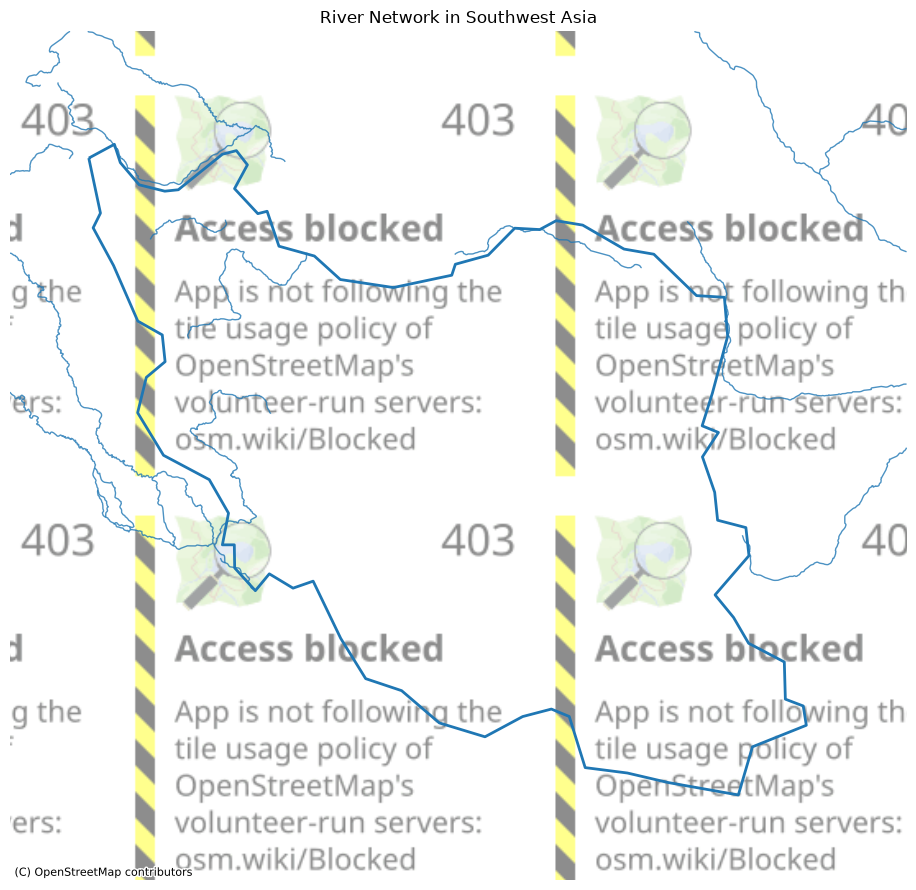

In [5]:
rivers_3857 = rivers_region.to_crs(epsg=3857)
study_3857 = study_area.to_crs(epsg=3857)
iran_3857 = iran.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11, 9))

rivers_3857.plot(
    ax=ax,
    linewidth=1.0,
    alpha=0.8
)

if len(iran_3857) == 1:
    iran_3857.boundary.plot(
        ax=ax,
        linewidth=2.0
    )

xmin, ymin, xmax, ymax = study_3857.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.OpenStreetMap.Mapnik,
        alpha=0.45
    )
except Exception as e:
    print("Basemap could not be loaded:", e)

ax.set_title("River Network in Southwest Asia")
ax.set_axis_off()
plt.tight_layout()
plt.show()


`Isolation Forest` یک الگوریتم **تشخیص ناهنجاری بدون‌ناظر** است.

در این پروژه مدل از چهار ویژگی استفاده می‌کند:

- طول رودخانه
- ضریب پیچ‌وخم
- طول جغرافیایی مرکز قطعه
- عرض جغرافیایی مرکز قطعه

ابتدا ویژگی‌ها استاندارد می‌شوند و سپس مدل آموزش می‌بیند.

خروجی مدل:

- `Normal` = قطعه معمولی
- `Anomaly` = قطعه غیرعادی

مقدار `contamination=0.12` یعنی مدل تقریباً ۱۲٪ داده‌ها را به‌عنوان کاندید ناهنجاری در نظر می‌گیرد.


In [6]:
feature_cols = [
    "length_km",
    "sinuosity",
    "centroid_lon",
    "centroid_lat"
]

X = rivers_region[feature_cols].copy()

if len(X) < 20:
    print(
        "Warning: sample size is small. "
        "The model will still run, but interpretation should be cautious."
    )

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(
    n_estimators=200,
    contamination=0.12,
    random_state=42,
    n_jobs=-1
)

prediction = model.fit_predict(X_scaled)
anomaly_score = -model.score_samples(X_scaled)

rivers_region["iforest_prediction"] = prediction
rivers_region["anomaly_score"] = anomaly_score
rivers_region["ai_label"] = np.where(
    prediction == -1,
    "Anomaly",
    "Normal"
)

print("Model trained successfully.")
print("\nClass counts:")
display(rivers_region["ai_label"].value_counts())


Model trained successfully.

Class counts:


ai_label
Normal     27
Anomaly     4
Name: count, dtype: int64

In [7]:
possible_name_cols = ["name_en", "NAME_EN", "name", "NAME"]
name_col = next(
    (c for c in possible_name_cols if c in rivers_region.columns),
    None
)

show_cols = []
if name_col:
    show_cols.append(name_col)

show_cols += [
    "length_km",
    "sinuosity",
    "centroid_lon",
    "centroid_lat",
    "anomaly_score",
    "ai_label"
]

print("Top 10 most unusual river segments:")
display(
    rivers_region[show_cols]
    .sort_values("anomaly_score", ascending=False)
    .head(10)
    .round(3)
)

print("\nAverage characteristics by AI class:")
display(
    rivers_region.groupby("ai_label")[feature_cols]
    .mean()
    .round(3)
)


Top 10 most unusual river segments:


,name_en,length_km,sinuosity,centroid_lon,centroid_lat,anomaly_score,ai_label
11,Karkheh,848.336,2.360,47.858,32.997,0.639,Anomaly
7,Helmand,468.610,1.755,63.035,30.673,0.620,Anomaly
15,Hari,934.337,1.422,62.286,35.395,0.600,Anomaly
25,Amu Darya,786.836,1.117,63.080,39.687,0.576,Anomaly
27,Kura,249.730,1.814,43.011,41.370,0.552,Normal
23,Zeravshan,289.453,1.284,64.632,39.837,0.545,Normal
6,Helmand,257.668,1.121,65.195,32.430,0.543,Normal
17,Qezel Uzan,490.237,2.158,48.151,36.756,0.541,Normal
19,Atrek,528.456,1.186,56.353,37.616,0.504,Normal
9,Euphrates,657.176,1.432,43.616,33.057,0.504,Normal



Average characteristics by AI class:


,length_km,sinuosity,centroid_lon,centroid_lat
ai_label,,,,
Anomaly,759.530,1.664,59.064,34.688
Normal,248.532,1.307,47.432,35.726


## سلول 8 — نمایش خروجی هوش مصنوعی روی نقشه ثابت

نتیجه مدل مستقیماً روی نقشه GIS نمایش داده می‌شود تا محل قطعات `Anomaly` قابل مشاهده باشد.


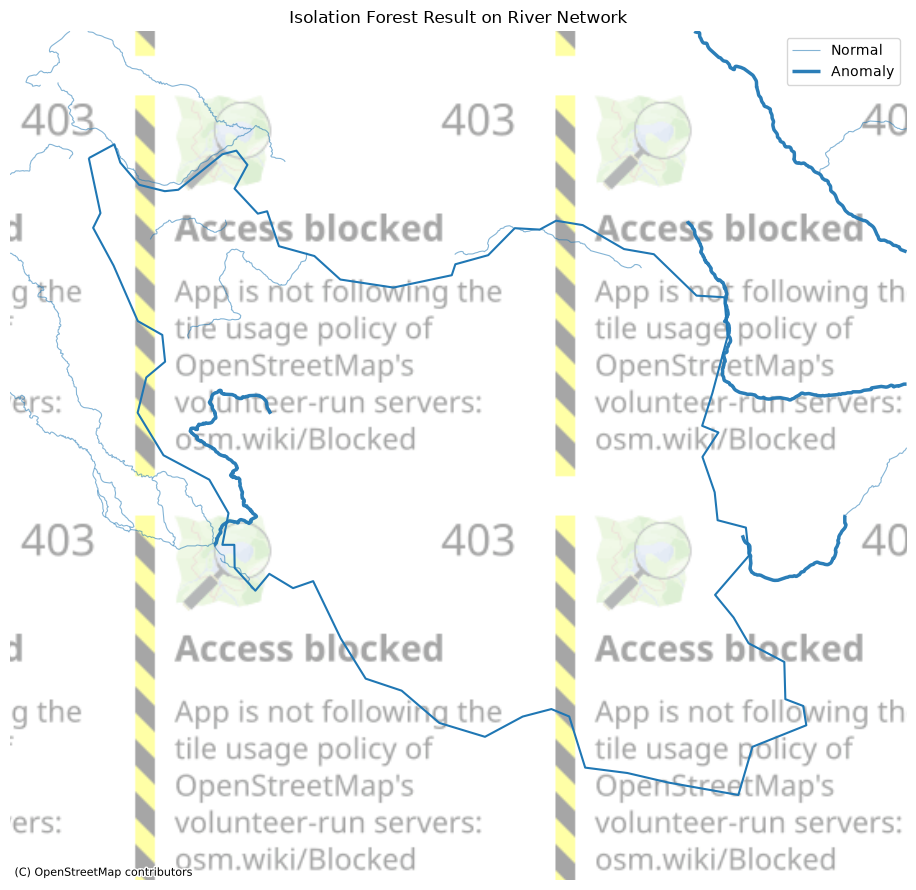

In [8]:
result_3857 = rivers_region.to_crs(epsg=3857)

normal = result_3857[result_3857["ai_label"] == "Normal"]
anomaly = result_3857[result_3857["ai_label"] == "Anomaly"]

fig, ax = plt.subplots(figsize=(11, 9))

normal.plot(
    ax=ax,
    linewidth=0.8,
    alpha=0.55,
    label="Normal"
)

anomaly.plot(
    ax=ax,
    linewidth=2.5,
    alpha=0.95,
    label="Anomaly"
)

if len(iran_3857) == 1:
    iran_3857.boundary.plot(
        ax=ax,
        linewidth=1.5
    )

xmin, ymin, xmax, ymax = study_3857.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.OpenStreetMap.Mapnik,
        alpha=0.35
    )
except Exception:
    pass

ax.set_title("Isolation Forest Result on River Network")
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [9]:
m = folium.Map(
    location=[32.5, 54],
    zoom_start=5,
    tiles="OpenStreetMap"
)

if len(iran) == 1:
    folium.GeoJson(
        iran.__geo_interface__,
        name="Iran boundary",
        style_function=lambda feature: {
            "color": "black",
            "weight": 2,
            "fillOpacity": 0
        }
    ).add_to(m)

for idx, row in rivers_region.iterrows():
    coords = [[lat, lon] for lon, lat in row.geometry.coords]

    is_anomaly = row["ai_label"] == "Anomaly"
    line_color = "red" if is_anomaly else "blue"
    line_weight = 4 if is_anomaly else 2
    line_opacity = 0.9 if is_anomaly else 0.45

    river_name = (
        str(row[name_col])
        if name_col and pd.notna(row[name_col])
        else f"Segment {idx}"
    )

    popup_text = (
        f"<b>Name:</b> {river_name}<br>"
        f"<b>AI class:</b> {row['ai_label']}<br>"
        f"<b>Length:</b> {row['length_km']:.2f} km<br>"
        f"<b>Sinuosity:</b> {row['sinuosity']:.3f}<br>"
        f"<b>Anomaly score:</b> {row['anomaly_score']:.3f}"
    )

    folium.PolyLine(
        locations=coords,
        color=line_color,
        weight=line_weight,
        opacity=line_opacity,
        popup=folium.Popup(popup_text, max_width=350)
    ).add_to(m)

folium.LayerControl().add_to(m)

html_path = "river_isolation_forest_map.html"
geojson_path = "river_isolation_forest_result.geojson"
csv_path = "river_isolation_forest_result.csv"

m.save(html_path)
rivers_region.to_file(geojson_path, driver="GeoJSON")

csv_cols = []
if name_col:
    csv_cols.append(name_col)

csv_cols += [
    "length_km",
    "straight_km",
    "sinuosity",
    "centroid_lon",
    "centroid_lat",
    "anomaly_score",
    "ai_label"
]

rivers_region[csv_cols].to_csv(csv_path, index=False)

print("Saved files:")
print("-", html_path)
print("-", geojson_path)
print("-", csv_path)

m


Saved files:
- river_isolation_forest_map.html
- river_isolation_forest_result.geojson
- river_isolation_forest_result.csv


## نتیجه‌گیری و تمرین‌ها

در این پروژه یک Workflow کامل انجام شد:

**Natural Earth → LineString → Spatial Clip → Reprojection → Feature Engineering → StandardScaler → Isolation Forest → Anomaly Detection → Static Map → Interactive Map**

تفاوت با پروژه قبلی:

| پروژه | نوع داده | الگوریتم |
|---|---|---|
| زلزله‌های ایران | Point | K-Means |
| رودخانه‌ها | LineString | Isolation Forest |

### پنج تمرین پیشنهادی

1. مقدار `contamination` را به `0.05`، `0.10` و `0.20` تغییر دهید و نقشه‌ها را مقایسه کنید.
2. ویژگی `scalerank` را در صورت موجود بودن به مدل اضافه کنید.
3. مدل را فقط برای رودخانه‌های داخل مرز ایران اجرا کنید.
4. به‌جای Isolation Forest از `LocalOutlierFactor` استفاده کنید.
5. ویژگی فاصله مرکز هر قطعه تا مرکز ایران را ایجاد کنید و اثر آن را بررسی کنید.

> `Anomaly` به معنی خطرناک بودن رودخانه نیست؛ فقط یعنی آن قطعه از نظر ویژگی‌های انتخاب‌شده با بیشتر نمونه‌ها متفاوت است.
